# Projeto Fundamentos de Aprendizagem Automática

**Grupo 22**

### Membros

- **jiyi Li** (62244)
    
- **oujie Wu** (62228)
    
- **josé lourenço** (62817)
    

  

## Problema

**Estimar a nota final** com base em variáveis comportamentais:

- `student_hour`
    
- `gaming_hours`
    
- `sleep_hours`
    
- `exercise_minutes`
    
- ...
    

        

## Variáveis-Alvo (Targets)

### 1. Cenário de Regressão (y)

Estimar **Exam Score** (nota de exame). Por exemplo, um valor contínuo entre **0 e 100**.

### 2. Cenário de Classificação (y)

Transformar a variável _Exam Score_ em categorias discretas e interpretáveis. Com base na distribuição dos dados ou em critérios pedagógicos, podemos definir:

**Classificação multiclass (Nota entre 0 até 65):**

|**Categoria**|**Intervalo (Exam Score)**|
|---|---|
|**Insuficiente**|0 a 12|
|**Suficiente**|13 a 25|
|**Bom**|26 a 38|
|**Muito bom**|39 a 65|


## Stakeholders

- Os próprios estudantes
    
- A instituição de ensino / Escola
    
- Conselheiros / Tutores
    
- Serviços de Apoio ao Estudante

        exam_score
0        Muito Bom
1     Insuficiente
2       Suficiente
3     Insuficiente
4              Bom
...            ...
4995    Suficiente
4996  Insuficiente
4997           Bom
4998  Insuficiente
4999  Insuficiente

[5000 rows x 1 columns]
      exam_score
0            3.0
1            0.0
2            1.0
3            0.0
4            2.0
...          ...
4995         1.0
4996         0.0
4997         2.0
4998         0.0
4999         0.0

[5000 rows x 1 columns]
None
Best parameters: {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best mean CV accuracy: 0.575


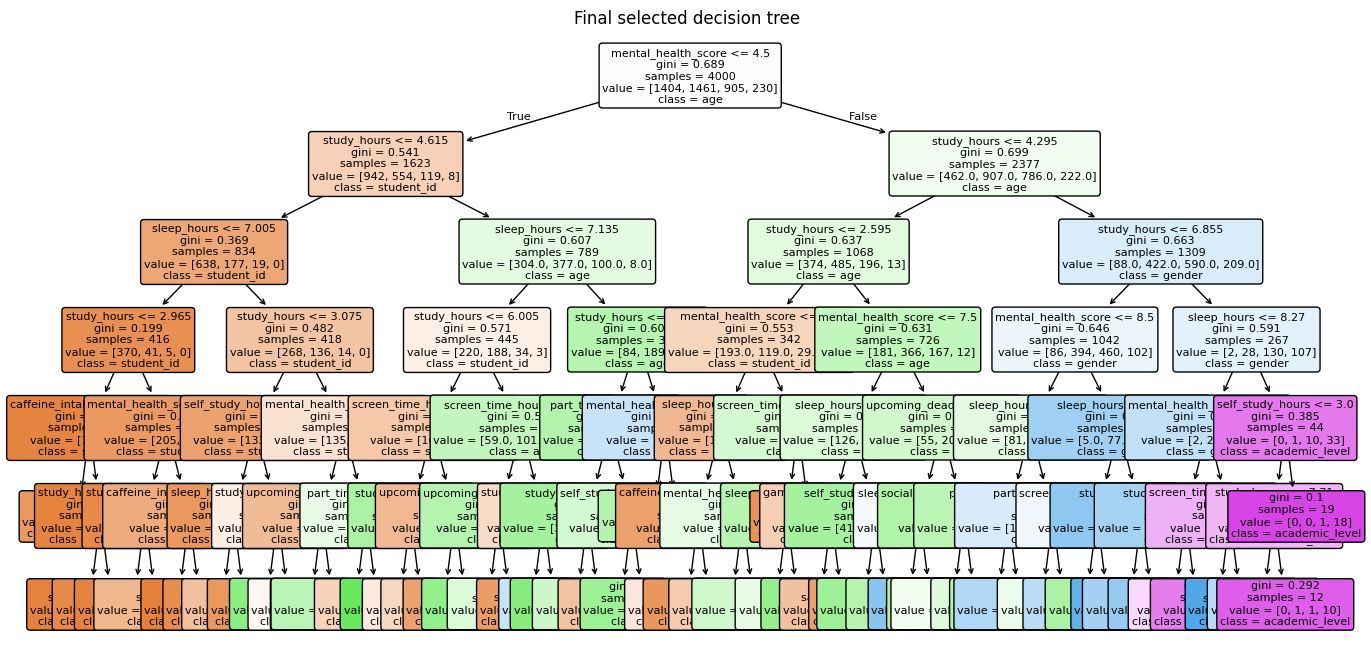

In [11]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import KFold, train_test_split
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pydot
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


def display_tree(the_tree, feature_names, class_names, fname=None, figsize=(10,10)):
    dot_data = tree.export_graphviz(
        the_tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        special_characters=True
    )

    graph = pydot.graph_from_dot_data(dot_data)[0]
    png = graph.create_png()

    img = mpimg.imread(io.BytesIO(png))

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(img)

    if fname:
        graph.write_png(f"{fname}.png")





# ler ficherio de stufent_records
df_student_records = pd.read_csv('student_records_full.csv')
df_colunas = df_student_records.columns


df_y = pd.DataFrame(df_student_records['exam_score'])
df_y_numerico = df_y["exam_score"]


def categorizar_exame_score(score):
    if 0 <= score < 13:
        return 'Insuficiente'
    elif 13 <= score < 26:
        return 'Suficiente'
    elif 26 <= score < 39:
        return 'Bom'
    else:
        return "Muito Bom"

df_y["exam_score"] = df_y['exam_score'].apply(categorizar_exame_score)


df_y_original = df_y.copy()  # 保留原始的分类标签
print(df_y_original)
categories = [["Insuficiente", "Suficiente", "Bom", "Muito Bom"]]
oe = OrdinalEncoder(categories=categories)
df_y["exam_score"] = oe.fit_transform(df_y[["exam_score"]])
print(df_y)



# print(df_y["exam_score"].value_counts()) #每个指标的数量统计
# print(df_y["exam_score"].value_counts(normalize=True)) #每个指标的比例统计



df_student_records.drop(columns=["student_id", "exam_score","productivity_score","burnout_level","focus_index"], inplace=True)
# print(df_student_records.columns)
df_categorico = df_student_records[["gender","academic_level","internet_quality"]]
df_student_records_copy = df_student_records.copy()
df_numerico = df_student_records.drop(columns=["gender", "academic_level", "internet_quality"], inplace=True)



df_X = pd.get_dummies(df_student_records_copy, columns=df_categorico.columns.values)
# print(df_X.columns)


X = df_X.values
y_categoria = df_y
print(df_numerico)

#Utilizando three/way split
X_learning, X_test, y_learning, y_test = train_test_split(
    X, y_categoria, test_size=0.2, random_state=7,stratify=y_categoria)

X_train, X_val, y_train, y_val = train_test_split(
    X_learning, y_learning, test_size=0.25, random_state=7,stratify=y_learning)


#3. Treino e Avaliação de Modelos Base


# Decision Tree

param_grid = {
"criterion": ["gini", "entropy"],
"max_depth": [1, 2, 3, 4, 5, 6, None],
"min_samples_split": [2, 5, 10, 20],
"min_samples_leaf": [1, 2, 5, 10],
}
grid = GridSearchCV(
estimator=tree.DecisionTreeClassifier(random_state=7),#固定随机种子确保可重复
param_grid=param_grid,#上面定义的超参数网格。
scoring="accuracy",#用准确率作为模型评估指标
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=7),#表示使用分层 5 折交叉验证，每折保持原始数据的类别比例，且打乱数据后划分。
n_jobs=-1#使用所有可用的 CPU 核心并行计算，加速搜索过程。
)
grid.fit(X_learning, y_learning) # 仅在学习集上训练和验证

print("Best parameters:", grid.best_params_)#返回交叉验证中平均得分最高的参数组合。
print("Best mean CV accuracy:", round(grid.best_score_, 3))#返回最佳参数组合对应的


#utilizando bestest parameters para treinar o modelo final
final_model = grid.best_estimator_ #- `grid.best_estimator_` 是 `GridSearchCV` 在找到最佳超参数后，使用**整个学习集**（`X_learning, y_learning`）重新训练得到的模型。
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]
final_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision (macro)": precision_score(y_test, y_test_pred, average='macro'),
    "Precision (weighted)": precision_score(y_test, y_test_pred, average='weighted'),
    "Recall (macro)": recall_score(y_test, y_test_pred, average='macro'),
    "Recall (weighted)": recall_score(y_test, y_test_pred, average='weighted'),
    "F1-score (macro)": f1_score(y_test, y_test_pred, average='macro'),
    "F1-score (weighted)": f1_score(y_test, y_test_pred, average='weighted'),
})

final_metrics.round(3)


plt.figure(figsize=(16, 8))
plot_tree(
final_model,
feature_names=df_X.columns,
class_names=df_colunas,
filled=True,
rounded=True,
fontsize=8,
)

plt.title("Final selected decision tree")
plt.show()

